### Importing necessary modules

In [2]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)

### Importing dataset

In [3]:
data_part_1 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part1-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_2 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part2-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_3 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part3-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_4 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part4-5nearest-dakar-with-storm-size.csv", index_col=False)
test_data = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-test-5nearest-dakar-with-storm-size.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [4]:
data = pd.concat([data_part_1, data_part_2, data_part_3, data_part_4])

In [5]:
data = data.dropna()
test_data = test_data.dropna()

In [6]:
lat_field = [f"lat{i}" for i in range(1, 6)]
lon_field = [f"lon{i}" for i in range(1, 6)]

#### Choosing field to include in the data

In [7]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')
data = data[field]

In [7]:
#query = r"`hour`>=15 and `hour`<=21"
#data = data.query(query)
#test_data = test_data.query(query)

In [8]:
#data = data[data["ds1"] <= 60*3]

### Exploratory data analysis

In [8]:
def cos_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.cos(i*np.pi/180))
            else:
                transformed.append(-9999)    
        df_copy[key] = transformed
    return df_copy

In [9]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(-9999)    
        df_copy[key] = transformed
    return df_copy

In [10]:
to_scale = wavelet_power + storm_size + distance

In [11]:
transform = True
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])
    data = cos_transform(data, location.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])
    test_data = cos_transform(test_data, location.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [12]:
train, validation = train_test_split(data, test_size=0.2, random_state=12)

In [13]:
x_train = train.drop([target_index], axis=1)
y_train = train[target_index]

x_val = validation.drop([target_index], axis=1)
y_val = validation[target_index]

x_test = test_data.drop([target_index], axis=1)
y_test = test_data[target_index]

#### Normalising the features

In [14]:
# normalise data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [15]:
def class_prediction(model, x, y):

    # predict the probability using the model
    y_hat = model.predict(x)  
    #y_hat = tf.nn.sigmoid(y_hat)
    
    # calculate Brier Score
    bs = brier_score_loss(y, y_hat)

    # compute auc
    auc = roc_auc_score(y, y_hat)

    return y_hat, auc, bs

In [16]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [17]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

### Performance on training data

In [18]:
model = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/best_model_with_weights.keras")

TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_1', 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_input_shape': [None, 30], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'dense_3_input'}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_3', 'trainable': True, 'dtype': 'float32', 'batch_input_shape': [None, 30], 'units': 16, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros'

### Performance on testing data

In [20]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

 90/579 [===>..........................] - ETA: 1s

579/579 [==============================] - 2s 3ms/step
0.15622963


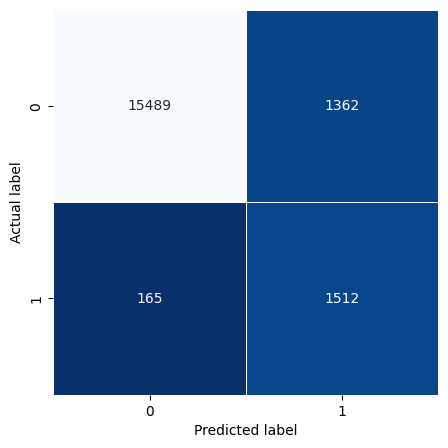

0.96


In [21]:
y_hat_val, auc_val, bs_val = class_prediction(model, x_val, y_val)
classification_threshold_val = cutoff_youdens_j(*roc_curve(y_val, y_hat_val))
print(classification_threshold_val)
plot_cm(y_val, y_hat_val, classification_threshold=classification_threshold_val)
print(f"{auc_val:.2f}")

In [22]:
average_precision_score(y_val, y_hat_val)

0.7655029574965371

556/556 [==============================] - 1s 2ms/step
0.08725337


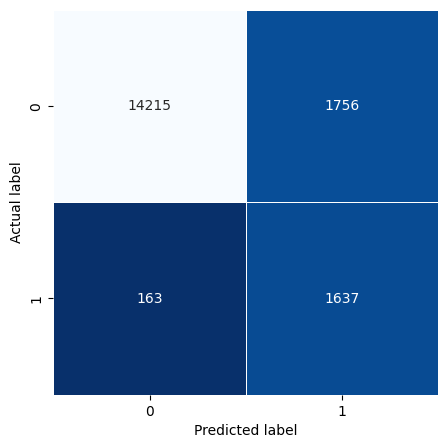

0.95
0.04254263911646327


In [23]:
y_hat_test, auc_test, bs_test = class_prediction(model, x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
print(classification_threshold)
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold)
print(f"{auc_test:.2f}")
print(bs_test)

In [24]:
average_precision_score(y_test, y_hat_test)

0.7524773601953724

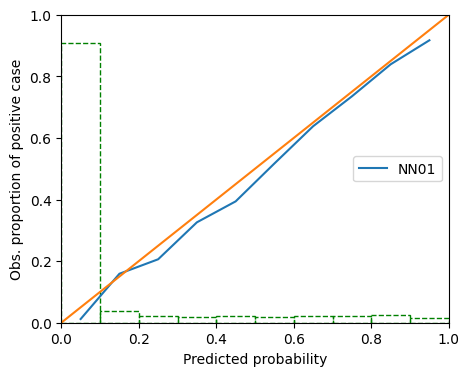

In [25]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN01")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.show()

In [26]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [27]:
y_hat_train, auc_train, bs_train = class_prediction(model, x_train, y_train)

  98/2316 [>.............................] - ETA: 5s

2316/2316 [==============================] - 4s 2ms/step


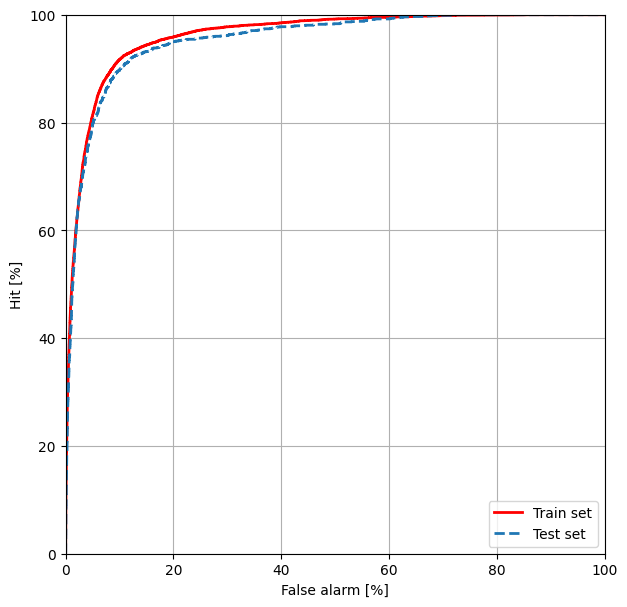

In [28]:
plot_roc("Train set", y_train, y_hat_train, color="red")
plot_roc("Test set", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.legend(loc='lower right');

In [29]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

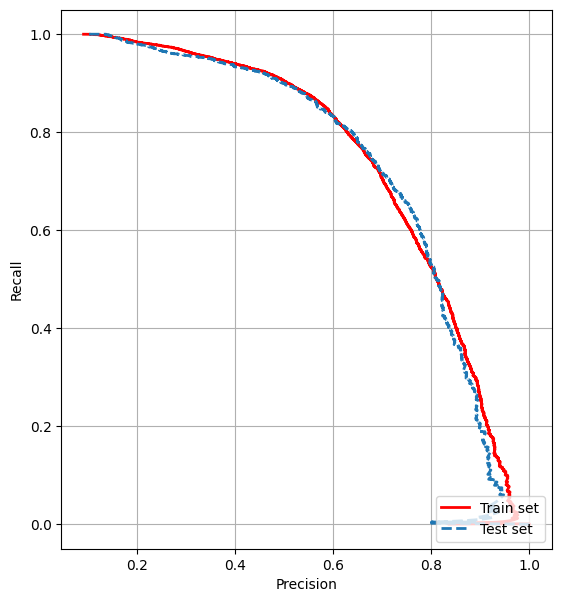

In [30]:
plot_prc("Train set", y_train, y_hat_train, color="red")
plot_prc("Test set", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.legend(loc='lower right');

In [31]:
pc = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/unconditional-probability/dataset-pc-31.csv")

In [32]:
pc = pc.dropna()
test_data =  test_data.dropna()

In [33]:
Cb_Dakar_unc = []
for i in range(len(test_data)):
    minute = test_data["minute"].values[i]    
    hour = test_data["hour"].values[i] + 1
    if hour != 24:    
        index_hour = pc["hour"].values == hour
    else:
        index_hour = pc["hour"].values == 0
    index_minute = pc["minute"].values == minute
    index = index_hour * index_minute
    Cb_Dakar_unc.append(pc["probability"].values[index])
Cb_Dakar_unc = np.array(Cb_Dakar_unc)

In [34]:
bs_ref = brier_score_loss(y_test, Cb_Dakar_unc)
bs_ref

0.09348868320015756

In [35]:
x_test.shape

(17771, 30)

In [36]:
y_hat_model = model.predict(x_test)

211/556 [==========>...................] - ETA: 0s

556/556 [==============================] - 1s 2ms/step


In [37]:
bs = brier_score_loss(y_test, y_hat_model)
bs

0.04254263911646327

In [38]:
bss = 1 - (bs/bs_ref)
bss

0.5449434342188748

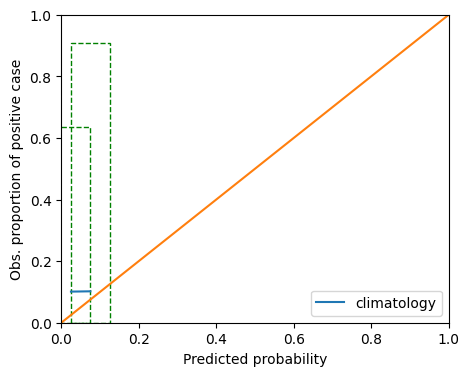

In [39]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, Cb_Dakar_unc.flatten(), bin_size=0.05, count_pred_per_bin=10)
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"climatology")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.show()

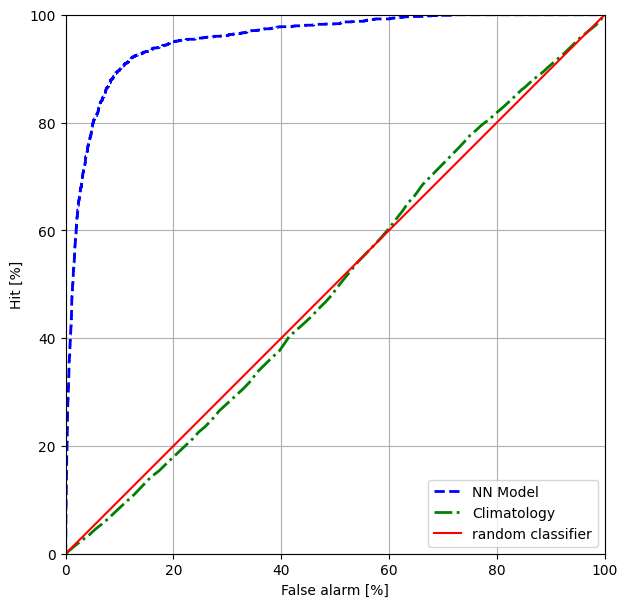

In [40]:
plot_roc("NN Model", y_test, y_hat_test, color="blue", linestyle='--')
plot_roc("Climatology", y_test, Cb_Dakar_unc, color="green", linestyle='-.')
plt.plot(range(0,101), range(0,101), color="red", label="random classifier")
plt.legend(loc='lower right');